<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_5_MutliClassClassification/18_5_2_Multiclass_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiclass Classification: Part 2
## Measuring Performance Class by Class

---

## What This Notebook Is About

The last notebook trained a penguin species classifier and showed the confusion matrix. The XGBoost model was nearly perfect — accuracy very close to 100%.

But "accuracy" collapses everything into one number. It hides which classes the model handles well and which it struggles with. And on harder, more realistic datasets, accuracy actively misleads you when some classes are much rarer than others.

This notebook builds the tools to look past accuracy:

1. **Per-class precision and recall** — performance broken down by class
2. **The F1 score** — one number per class that balances precision and recall
3. **The averaging problem** — how to combine class scores into a single summary
4. **Macro vs. weighted F1** — two different answers to "is this model good?"

**What you will learn:**
- Why accuracy alone is insufficient for multiclass problems
- How precision and recall extend to three or more classes
- The difference between macro and weighted averaging — and when each is the right choice
- How to read a classification report with confidence

## Setup

We rebuild the penguin dataset from the last notebook. To give us interesting per-class numbers to work with, we will start with a **shallow Decision Tree** — a deliberately simple model — and then compare it to our full XGBoost. Simple models often fail on specific classes in informative ways.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, f1_score,
                              precision_score, recall_score)

sns.set_theme(style="whitegrid")

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
penguins = pd.read_csv(url).dropna().reset_index(drop=True)

species_names = ["Adelie", "Chinstrap", "Gentoo"]
species_map = {name: i for i, name in enumerate(species_names)}
y = penguins["species"].map(species_map).to_numpy()

features = pd.get_dummies(
    penguins.drop(columns=["species"]),
    columns=["island", "sex"], drop_first=False
)
X = features.to_numpy(dtype=float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Shallow decision tree: limited capacity, will make some instructive mistakes
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("Shallow Decision Tree (max_depth=3) trained.")

Shallow Decision Tree (max_depth=3) trained.


---

## Section 1: The Limits of Accuracy

### A Single Number Is Not Enough

The shallow Decision Tree gets about 96% accuracy on the test set. That sounds impressive. But ask a harder question:

> *When the tree gets a penguin wrong, which species does it confuse it for?*

Accuracy cannot answer that. It treats all errors equally — a Chinstrap-as-Adelie mistake and a Gentoo-as-Adelie mistake both just subtract one from the total correct count.

To understand the model's behavior, you need per-class metrics.

### Precision and Recall, Revisited

You learned precision and recall in Unit 18.1 for binary problems. The definitions extend directly:

**Precision for class C:** Of all the samples the model *predicted* as class C, what fraction actually *were* class C?
> "When I say it's Chinstrap, how often am I right?"

**Recall for class C:** Of all the samples that *actually are* class C, what fraction did the model correctly *identify*?
> "Of the actual Chinstraps, how many did I catch?"

The only change going from binary to multiclass: compute precision and recall **once per class**, treating each class as the "positive" class in turn.

### A Tiny Worked Example

Before running sklearn, let us compute precision and recall by hand from a small confusion matrix.

Suppose you have three bird species — Sparrow, Robin, Hawk — and 12 test birds:

| | Pred Sparrow | Pred Robin | Pred Hawk |
|---|---|---|---|
| **Actual Sparrow** | 4 | 1 | 0 |
| **Actual Robin** | 2 | 3 | 0 |
| **Actual Hawk** | 0 | 0 | 2 |

**Precision for Robin:**
- The model predicted "Robin" for: 1 Sparrow, 3 Robins, 0 Hawks = 4 "Robin" predictions total
- Of those 4, only 3 were actual Robins
- Precision = 3 / 4 = **0.75**

**Recall for Robin:**
- There were 5 actual Robins (row sum: 2 + 3 + 0 = 5)
- The model caught 3 of them
- Recall = 3 / 5 = **0.60**

The model is reasonably precise about Robin (when it says Robin, 75% chance it is right) but misses 40% of the actual Robins (calling them Sparrow instead).

In [2]:
# Verify the toy example with sklearn
toy_actual    = [0,0,0,0,0, 1,1,1,1,1, 2,2]  # 0=Sparrow 1=Robin 2=Hawk
toy_predicted = [0,0,0,0,1, 0,0,1,1,1, 2,2]
toy_names = ["Sparrow", "Robin", "Hawk"]

print("Toy confusion matrix:")
print(confusion_matrix(toy_actual, toy_predicted))
print()

print("Per-class precision (fraction of predicted class C that is actually C):")
for name, p in zip(toy_names, precision_score(toy_actual, toy_predicted, average=None)):
    print(f"  {name:<8} precision = {p:.2f}")

print()
print("Per-class recall (fraction of true class C that was correctly identified):")
for name, r in zip(toy_names, recall_score(toy_actual, toy_predicted, average=None)):
    print(f"  {name:<8} recall    = {r:.2f}")

Toy confusion matrix:
[[4 1 0]
 [2 3 0]
 [0 0 2]]

Per-class precision (fraction of predicted class C that is actually C):
  Sparrow  precision = 0.67
  Robin    precision = 0.75
  Hawk     precision = 1.00

Per-class recall (fraction of true class C that was correctly identified):
  Sparrow  recall    = 0.80
  Robin    recall    = 0.60
  Hawk     recall    = 1.00


The numbers match our hand calculation. Now let us apply this to the penguin model.

---

## Section 2: Per-Class Performance on Penguins

In [3]:
# Per-class precision, recall, and F1 for the shallow tree
prec = precision_score(y_test, y_pred_tree, average=None)
rec  = recall_score(y_test, y_pred_tree, average=None)
f1   = f1_score(y_test, y_pred_tree, average=None)
supp = np.bincount(y_test)

print("Shallow Decision Tree — per-class performance:\n")
header = "  {:<12}  {:>10}  {:>8}  {:>6}  {:>8}".format(
    "Species", "Precision", "Recall", "F1", "Support")
print(header)
print("  " + "-" * (len(header) - 2))
for i, name in enumerate(species_names):
    print("  {:<12}  {:>10.3f}  {:>8.3f}  {:>6.3f}  {:>8}".format(
        name, prec[i], rec[i], f1[i], supp[i]))

Shallow Decision Tree — per-class performance:

  Species        Precision    Recall      F1   Support
  ----------------------------------------------------
  Adelie             0.906     1.000   0.951        29
  Chinstrap          1.000     0.929   0.963        14
  Gentoo             1.000     0.917   0.957        24


Study the numbers. Even 96% overall accuracy hides meaningful per-class differences.

- **Adelie recall = 1.00:** The tree catches every Adelie, likely because Adelie is the largest class (44%) and the tree learned to predict it broadly.
- **Chinstrap recall = 0.93:** The tree misses one Chinstrap out of 14. Chinstrap is the smallest class, so one miss is already a 7% error rate.
- **Gentoo recall = 0.92:** The tree misses two Gentoos. But notice — Gentoo precision is also 1.00, meaning when it calls something "Gentoo" it is always right. The errors go the other direction: Gentoos being called something else.

The confusion matrix will show exactly which direction the errors flow.

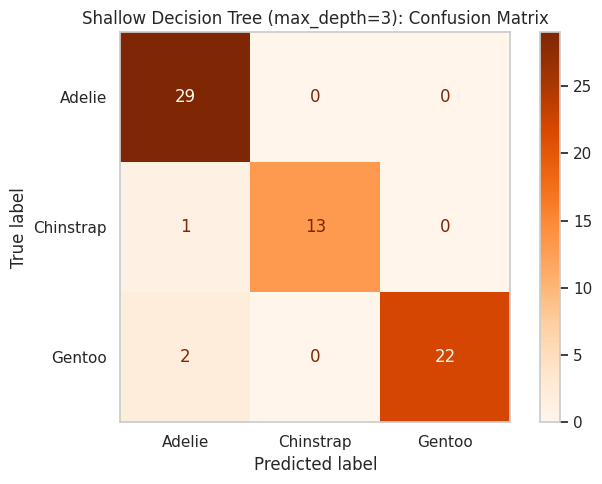

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tree,
    display_labels=species_names,
    cmap="Oranges",
    ax=ax
)
ax.set_title("Shallow Decision Tree (max_depth=3): Confusion Matrix", fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.show()

The off-diagonal cells confirm what the recall numbers suggested. Missed Chinstraps tend to be called Adelie (the species that overlaps in body size). Missed Gentoos are also sometimes called Adelie.

The shallow tree's decision boundary is too coarse — it falls back to Adelie when uncertain. A deeper tree or an ensemble would use more features to resolve those borderline cases.

---

## Section 3: The F1 Score

You now have two numbers per class: precision and recall. They are complementary — high precision means few false positives, high recall means few false negatives. You cannot maximize both simultaneously without a perfect model.

The **F1 score** combines them into one number per class using the harmonic mean:

F1 = 2 × (precision × recall) / (precision + recall)

The harmonic mean is deliberately harsh: it drags the score toward the *lower* of the two values. A model with precision=1.00 and recall=0.50 gets F1=0.667, not 0.75. The penalty for a lopsided precision/recall trade-off is intentional.

In [5]:
# Demonstrate the harmonic mean penalty
examples = [
    ("Perfect balance",  0.90, 0.90),
    ("High prec / low rec", 1.00, 0.50),
    ("Low prec / high rec", 0.50, 1.00),
    ("Moderate both",   0.70, 0.70),
]

print(f"  {'Scenario':<26}  {'Precision':>10}  {'Recall':>8}  {'F1 (harmonic)':>14}  {'Arith. mean':>12}")
print("  " + "-" * 78)
for label, p, r in examples:
    f1_harmonic = 2 * p * r / (p + r)
    f1_arith    = (p + r) / 2
    print(f"  {label:<26}  {p:>10.2f}  {r:>8.2f}  {f1_harmonic:>14.3f}  {f1_arith:>12.3f}")
print()
print("Notice: the harmonic mean punishes lopsided precision/recall harder than the arithmetic mean.")

  Scenario                     Precision    Recall   F1 (harmonic)   Arith. mean
  ------------------------------------------------------------------------------
  Perfect balance                   0.90      0.90           0.900         0.900
  High prec / low rec               1.00      0.50           0.667         0.750
  Low prec / high rec               0.50      1.00           0.667         0.750
  Moderate both                     0.70      0.70           0.700         0.700

Notice: the harmonic mean punishes lopsided precision/recall harder than the arithmetic mean.


---

## Section 4: The Averaging Problem

You now have three F1 scores — one per class. Fine for a detailed audit. But sometimes you need **one number** to compare two models or to report performance.

How do you roll three F1 scores into one?

There are two common strategies, and they can give very different answers.

### Strategy 1: Macro Averaging — All Classes Equal

Add up the per-class F1 scores and divide by the number of classes. Each class gets equal weight regardless of how many samples it has.

Macro F1 = (F1_Adelie + F1_Chinstrap + F1_Gentoo) / 3

**Use macro when:** All classes matter equally to you, regardless of how common they are. If Chinstrap is the least common but just as important as Adelie, macro average is the honest metric.

### Strategy 2: Weighted Averaging — Frequent Classes Count More

Multiply each class F1 by that class's share of the total samples, then sum.

Weighted F1 = (F1_Adelie × support_Adelie + ...) / total_samples

**Use weighted when:** Class frequency reflects real-world importance. If Adelie makes up 44% of the dataset and Adelie errors are the most common kind of error in practice, letting Adelie count more is sensible.

In [6]:
# Compute both averages manually to make the calculation transparent
f1_per_class = f1_score(y_test, y_pred_tree, average=None)
support      = np.bincount(y_test)

macro_f1    = f1_per_class.mean()
weighted_f1 = np.sum(f1_per_class * support) / support.sum()

print(f"Per-class F1:  Adelie={f1_per_class[0]:.3f}, "
      f"Chinstrap={f1_per_class[1]:.3f}, Gentoo={f1_per_class[2]:.3f}")
print()
print(f"Macro F1    = ({' + '.join(f'{v:.3f}' for v in f1_per_class)}) / 3 = {macro_f1:.3f}")
print()
wterms = ' + '.join(f'{f1_per_class[i]:.3f}×{support[i]}' for i in range(3))
print(f"Weighted F1 = ({wterms}) / {support.sum()} = {weighted_f1:.3f}")
print()
print(f"Gap: {abs(weighted_f1 - macro_f1):.4f}")
print()
print("Note: The gap is small here because penguin classes are roughly balanced (29/14/24).")
print("When classes are severely imbalanced, this gap becomes the key diagnostic.")

Per-class F1:  Adelie=0.951, Chinstrap=0.963, Gentoo=0.957

Macro F1    = (0.951 + 0.963 + 0.957) / 3 = 0.957

Weighted F1 = (0.951×29 + 0.963×14 + 0.957×24) / 67 = 0.955

Gap: 0.0014

Note: The gap is small here because penguin classes are roughly balanced (29/14/24).
When classes are severely imbalanced, this gap becomes the key diagnostic.


For a balanced dataset like penguins, macro and weighted F1 are nearly identical. That is expected — when class sizes are equal, weighting by class size does nothing.

### The Gap as a Diagnostic

> **A large gap between macro F1 and weighted F1 is a warning sign.**

It signals that the model performs very differently across classes, and that a common class is papering over poor performance on a rare class.

- **Weighted F1 is high, macro F1 is low** → The model is doing well on frequent classes but failing on rare ones. The failure is exactly what weighted F1 hides.

The next notebook shows this in dramatic form: a medical dataset where the rarest class is the most dangerous, and where choosing weighted F1 over macro F1 leads you to trust a model that is missing the cases that matter most.

---

## Section 5: The Full Classification Report

In [7]:
# The classification report puts everything together
print("Shallow Decision Tree:")
print(classification_report(y_test, y_pred_tree, target_names=species_names, digits=3))

Shallow Decision Tree:
              precision    recall  f1-score   support

      Adelie      0.906     1.000     0.951        29
   Chinstrap      1.000     0.929     0.963        14
      Gentoo      1.000     0.917     0.957        24

    accuracy                          0.955        67
   macro avg      0.969     0.948     0.957        67
weighted avg      0.959     0.955     0.955        67



Walk through the report from top to bottom:

**Per-class rows (Adelie, Chinstrap, Gentoo):**
- `precision` — of everything predicted as this class, what fraction was correct
- `recall` — of everything actually in this class, what fraction was found
- `f1-score` — harmonic mean of precision and recall; low on either → low F1
- `support` — how many test samples belong to this class

**Bottom rows:**
- `accuracy` — overall fraction correct (same as before)
- `macro avg` — simple average of per-class metrics; all classes equal weight
- `weighted avg` — support-weighted average; frequent classes count more

In [8]:
# Compare shallow tree vs. full XGBoost
xgb_model = xgb.XGBClassifier(
    objective="multi:softprob", num_class=3,
    n_estimators=100, max_depth=4, learning_rate=0.1,
    random_state=42, eval_metric="mlogloss"
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("Full XGBoost model:")
print(classification_report(y_test, y_pred_xgb, target_names=species_names, digits=3))

Full XGBoost model:
              precision    recall  f1-score   support

      Adelie      1.000     1.000     1.000        29
   Chinstrap      1.000     1.000     1.000        14
      Gentoo      1.000     1.000     1.000        24

    accuracy                          1.000        67
   macro avg      1.000     1.000     1.000        67
weighted avg      1.000     1.000     1.000        67



The XGBoost model achieves perfect scores on this dataset. The penguins are nearly perfectly separable with the right model — all the confusion matrix errors disappear with 100 boosted trees vs. a single 3-level tree.

Two lessons:
1. Per-class metrics reveal where a weak model is failing, even when overall accuracy looks good.
2. The same per-class metrics confirm that a stronger model has eliminated those failures — class by class, not just on average.

---

## Section 6: Try It Yourself

Here is a confusion matrix from a 3-class model predicting tomorrow's weather: Sunny, Rainy, Cloudy.

| | Pred Sunny | Pred Rainy | Pred Cloudy |
|---|---|---|---|
| **Actual Sunny** | 18 | 2 | 0 |
| **Actual Rainy** | 3 | 12 | 5 |
| **Actual Cloudy** | 0 | 4 | 6 |

Your tasks:
1. Compute precision and recall for "Rainy" by hand.
2. Compute the F1 score for "Rainy".
3. Would macro F1 be higher or lower than weighted F1 here? Explain your reasoning without computing the exact numbers.

In [9]:
# Reconstruct the confusion matrix as arrays to verify your hand work
weather_actual    = []
weather_predicted = []
weather_cm = np.array([[18,2,0],[3,12,5],[0,4,6]])
for true_c in range(3):
    for pred_c in range(3):
        n = weather_cm[true_c, pred_c]
        weather_actual    += [true_c] * n
        weather_predicted += [pred_c] * n

weather_names = ["Sunny", "Rainy", "Cloudy"]

# TODO: Uncomment to check your work
# print(classification_report(weather_actual, weather_predicted, target_names=weather_names))

In [10]:
# @title Execute to see solution
solution = '''
Rainy precision:
  Column "Pred Rainy": 2 (Sunny) + 12 (Rainy) + 4 (Cloudy) = 18 total "Rainy" predictions
  Of those 18, only 12 were actually Rainy
  Precision = 12 / 18 = 0.667

Rainy recall:
  Row "Actual Rainy": 3 + 12 + 5 = 20 actual Rainy cases
  Model found 12 of them
  Recall = 12 / 20 = 0.600

Rainy F1 = 2 × (0.667 × 0.600) / (0.667 + 0.600) = 0.632

Macro vs. weighted F1 reasoning:
  Support: Sunny=20, Rainy=20, Cloudy=10. Total=50.
  Cloudy is the weakest class (F1 ≈ 0.57) and also the smallest (10/50 = 20%).
  Weighted F1 gives Cloudy less weight, so it will be higher than macro F1.
  Macro F1 penalizes Cloudy equally — lower overall.
'''
print(solution)


Rainy precision:
  Column "Pred Rainy": 2 (Sunny) + 12 (Rainy) + 4 (Cloudy) = 18 total "Rainy" predictions
  Of those 18, only 12 were actually Rainy
  Precision = 12 / 18 = 0.667

Rainy recall:
  Row "Actual Rainy": 3 + 12 + 5 = 20 actual Rainy cases
  Model found 12 of them
  Recall = 12 / 20 = 0.600

Rainy F1 = 2 × (0.667 × 0.600) / (0.667 + 0.600) = 0.632

Macro vs. weighted F1 reasoning:
  Support: Sunny=20, Rainy=20, Cloudy=10. Total=50.
  Cloudy is the weakest class (F1 ≈ 0.57) and also the smallest (10/50 = 20%).
  Weighted F1 gives Cloudy less weight, so it will be higher than macro F1.
  Macro F1 penalizes Cloudy equally — lower overall.



---

## Section 7: Choosing the Right Metric

| Situation | Recommended metric |
|---|---|
| All classes matter equally (regardless of size) | **Macro F1** |
| Class frequency reflects real-world importance | **Weighted F1** |
| You care most about a specific class | **Per-class recall or F1 for that class** |
| Classes are balanced | Macro ≈ weighted; either works |
| Classes are imbalanced + minority class is important | **Macro F1** (weighted would hide poor minority performance) |

The penguins were balanced enough that both averages told the same story. The next notebook takes this to the other extreme: a dataset where one class is both rare and medically critical, and where picking the wrong averaging strategy will make a dangerous model look acceptable.

---

## Putting It All Together

| Concept | What it means |
|---|---|
| Per-class precision | Of all predictions for class C, what fraction is correct |
| Per-class recall | Of all actual class C samples, what fraction was found |
| F1 score | Harmonic mean of precision and recall; penalizes lopsided trade-offs |
| Macro F1 | Simple average of per-class F1; treats all classes equally |
| Weighted F1 | Support-weighted average; frequent classes count more |
| Macro vs. weighted gap | Large gap = model performs differently across classes; minority class may be failing |

The story so far:

1. Accuracy hides per-class performance — even a 96% accurate model can miss a specific class at a 7–8% rate.
2. Precision and recall extend naturally to multiclass: compute them separately for each class.
3. The F1 score combines precision and recall; its harmonic mean punishes lopsided trade-offs.
4. To get a single summary, choose: macro (equal class weight) or weighted (proportional class weight).
5. When classes are balanced, the two averages converge. When they diverge, it is a signal.

**Where we are going next:** The hardest version of this problem — when one class is rare *and* medically critical. The gap between macro and weighted F1 will be large, and choosing the wrong metric will lead you to trust a model that is missing the cases that matter most.